In [ ]:
%reset -f

### Registration using "registrator" - a wrapper for Simple ITK


This demo-notebook explains how to use the "registrator"-wrapper for Simple ITK. The following packages are needed: Simple-ITK, CIL, numpy, os, matplotlib, importlib, plotly, jupytaer notebook (>>> conda install notebook), random and copy. All of these can be installed using pip install or conda install. CIL is only used to load data, and nothing else...

You will need the .py files
"plot_library.py" and "registrator.py"

In the demo we show how to register two volumes: These are x-ray and neutron reconstructions of the black beauty meteorite, slice B. The reconstructions are obtianed using FBP. Both volumes are around 1000³ voxels.

In this demo, the data is normalized to have values between zero and one. After normalization, some characteristics of the data are:
    - X-ray: Background value is around 0.1, intensity values in the meteorite around 0.8. 0.2 is a good threshold value. In the volume, a cylinder around the meteorite is visible. The noise is generally low.
    - Neutron: The background is around 0.4 and meteorite intensity around 0.6. A good threshold value is 0.5. The neutron data is much more noisy. This is why the intensity values get concentrated around 0.5 during the normalizatoin.

Running this demo takes XX minutes with te default options on the HPC (on the default processor on the linuxsh node).


#### Import libraries

In [ ]:
from cil.io import ZEISSDataReader
import numpy as np
import os
#current_directory = os.getcwd()
os.chdir('/zhome/71/c/146676/Desktop/msaca/main/')  # Navigate into a subdirectory
#print("Current working directory:", current_directory)
import matplotlib.pyplot as plt
from cil.io import TIFFStackReader, TIFFWriter
import plot_library as pl
import SimpleITK as sitk
import importlib
import registrator
import plotly.io as pio
pio.renderers.default = "notebook"
from cil.framework import ImageData, ImageGeometry

#### Define paths for data (change this)

In [ ]:
#reconpath0 = "/home/msaca/Data/sliceB_xray_dtu/sliceB_xray_dtu/blackbeauty__2023-01-11_114644/LFOV_12p6um_60kV_LE1/blackbeauty__LFOV_12p6um_60kV_LE1_recon.txm"
reconpath0 = "/dtu-compute/msaca/sliceA_xray_pc/estrids_recon/xray_3um_reslice_itksnap.tif"



#reconpath_neutron = "/home/msaca/Data/sliceB_neutron_dtu/sliceB_neutron_psi/04_evaluation/fullrecon/"
reconpath_neutron = "/dtu-compute/msaca/sliceA_neutron_psi/My_reconstructions/"

#### Load x-ray data and normalize using the pl module (from plot_library.py)

In [ ]:
recon_xray_ = sitk.ReadImage(reconpath0)
recon_xray_ = sitk.GetArrayFromImage(recon_xray_)
recon_xray = pl.array_normalizer(recon_xray_.astype(np.float32))

#### Load neutron data and normalize using the pl module (from plot_library.py)

In [ ]:
reader = TIFFStackReader(reconpath_neutron)
recon_neutron = pl.array_normalizer(reader.read())

#### Reload registrator class

(Using .reload(), you can change registrator.py, save the changes and apply them, without having to restart the kernel and reload the data)

In [517]:
importlib.reload(registrator)

<module 'registrator' from '/zhome/71/c/146676/Desktop/msaca/main/registrator.py'>

#### Initialize a Registratior() class object, "reg", and load in data.

The class contains two important members: reg.fixed and reg.moving. These are the two volumes we want to register. These are simpleITK images.

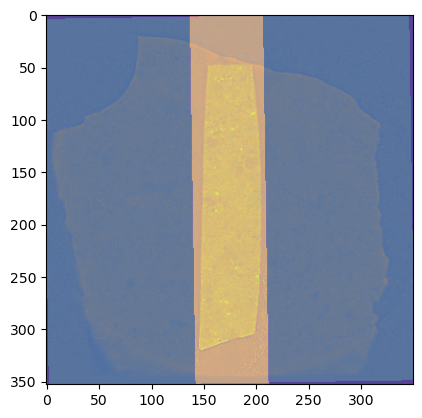

In [519]:
reg = registrator.Registrator()
reg.load_images(fixed_array=recon_neutron,moving_array=recon_xray)
threshold = [0.4,0.32]
#reg.resample(padding=[200,200,200],fixed=True)
reg.plot2d(thresholds = threshold,difference=False,moving=False)

The Registrator class has 3 methods worth remembering:

.transformation(): 
    - Input: Some options specifying with transformation to create
    - Output: A transformation: A class object in simpleITK
    Description: The goal of this class is to create a custom (user defined transformation)

.register():
    - Input: Options specifying options for the registration
    - Output: A transformation
    Description: The goal of this class is to create a transformation, which (when applied to reg.moving) will register reg.fixed with reg.moving.

.resample():
    - Input: A transformation
    - Output: None (or a simpleITK image)
    Description: Applies a transformation to either reg.moving (default) or reg.fixed () using interpolation.
    If in_place=True, the transformation is applied in place to either reg.moving or reg.fixed (the old volume is overwritten). If in_place=False, the transformed volume is returned

There are two auxilliary methods that are also used:
.apply_mean():
    - Input: A sitk image (for example reg.fixed or reg.moving), and a filter kernel size, "smooth".
    - Output: A sitk image
    Description: Filters the input image with a mean filter with kernel size "smooth"

.plot2d()
    - Input: Threshold values (a list with two elements, thresholding reg.fixed and reg.moving), difference
    - Output: None
    Description: Plots reg.fixed and reg.moving overlayed on each other. if difference=True, the difference in the threholded volumes are plotted. The plot is a slice along the two principal axes of the meteorite. The slice with the largest mass is chosen. The thresholding values are very important.




#### Get centroid transformation and apply

This transformation places the two images in te same coordinate system, and aligns the centroids of the images.

itk::simple::Euler3DTransform
 Euler3DTransform (0x557ae9ed38d0)
   RTTI typeinfo:   itk::Euler3DTransform<double>
   Reference Count: 1
   Modified Time: 274840511
   Debug: Off
   Object Name: 
   Observers: 
     none
   Matrix: 
     0.998453 -0.012715 0.054137 
     -0.0159797 -0.998052 0.0603051 
     0.0532648 -0.0610769 -0.996711 
   Offset: [0, 0, 0]
   Center: [0, 0, 0]
   Translation: [0, 0, 0]
   Inverse: 
     0.998453 -0.0159797 0.0532648 
     -0.012715 -0.998052 -0.0610769 
     0.054137 0.0603051 -0.996711 
   Singular: 0
   AngleX: -0.0611149
   AngleY: -3.0882
   AngleZ: 3.12885
   ComputeZYX: Off

Resampling the transformation
Resampling moving image


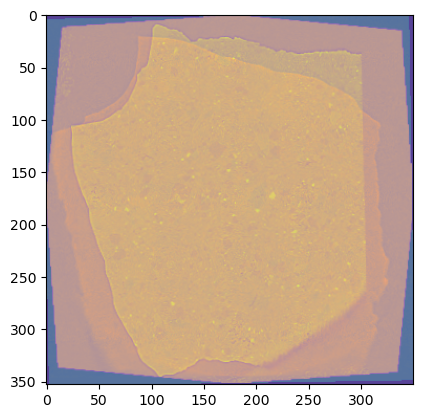

In [522]:
principals = reg.compute_principal_moments_and_axes(thresholds = [0.4,0.32],factor = 3)
matrix_fixed = principals['fixed']['axes']
moment_fixed = principals['fixed']['moment']
matrix_moving = principals['moving']['axes']
moment_moving = principals['moving']['moment']
matrix = (matrix_moving@matrix_fixed.T).flatten()
transform = reg.transformation(type='Euler3DTransform', matrix=matrix,translation=(0,0,0), thresholds = threshold)
reg.resample(transform)
reg.plot2d(thresholds = threshold,difference=False,moving=False)

#### Plot the resulting volumes

#### Rotate the volume around the zero'th axis and plot

By trial and error, I found that applying registration without flipping the reg.moving volume, resulted in a local minima in the registration, where the meteorite had been flipped. Here you can see how to define a transformation matrix and apply it...

#### Precompute smoothed versions of the neutron image (reg.moving)

This precomputed some smoothed images and saves them in a dictionary. This is used in the registration to speed it up. If smooting is specified during registration, the smoothing is calculated on the fly. Calculating the smoothed images in advance trades memory for speed. (Higher speed if calculated in advance, but higher memory usage). 

In [523]:
reg.fixed_smooth['2'] = reg.apply_mean(reg.fixed, smooth=2)

#### Do first registration loop

The following settings are set:

Learning rate: 10 (this is relatively high. Start with a high value and lower it for the next loops). The learning rate is the step size in the optimization algorithm.

Sampling percentage: The percentage of pixels used in the volume for calculaing the loss function of the registration. Minimum 0, maximum 1. The computation time scales linearly with the sampling percentage.

max_iter: Numer of iterations in the optimization loop.

metric_type: 'ms'/'ls' or 'mmi'. Specifying 'ms' or 'ls' used mean squares as the loss function. As the intensity values differ in the images, a threshold is used on both images to determine what is stone and what is not. Currently only the mean squares loss works for this example. mmi is the mattes mutual information.

optimizer type: 'gd' Currently only gd=gradient descent is supported.

smoothing: Apply smoothing to either reg.fixed or reg.moving. Set to smoothing=0 to apply no smoothing. Set to smoothing=2 , 3 , 4 , 5 to apply smoothing with these kernel sizes. In order to use reg.moving_smooth['N'] or reg.fixed_smooth['N'], set smoothing = N, where N is 2,3,4,5...

smooth_fixed, smooth_moving: True or False, set to true to apply smoothing, false if not.

Shrinking: Shrinks the image by shrinking in each dimension. This greatly reduces the computaion time by a factor of shrinking³. 

thresholds: The threshold values used in the least squares

Using precalculated smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 0.687456 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.7532935411371966
The current learning rate is 3.0
Iteration 20: Metric Value = 0.42975709254367067, Metric Difference = 0.3235364485935259
The current learning rate is 3.0
Iteration 40: Metric Value = 0.0024885596875517525, Metric Difference = 0.42726853285611893
The current learning rate is 3.0
Iteration 60: Metric Value = 0.0021374110983186203, Metric Difference = 0.00035114858923313225
The current learning rate is 3.0
Iteration 80: Metric Value = 0.0021097571369303064, Metric Difference = 2.765396138831389e-05
The current learning rate is 3.0
Iteration 100: Metric Value = 0.0021008618644661713, Metric Difference = 8.895272464135105e-06
The current learning rate is 3.0
Iteration 120: Metric Value = 0.0020912806398031107, Metric Difference = 9

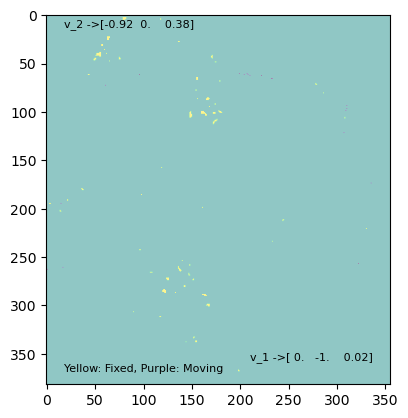

In [524]:
transform_registration= reg.register(learning_rate = 3, sampling_percentage = 0.3, max_iter = 200,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 2, shrinking = 5, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True,moving=True)

#### Do registration with smaller learning rate, smaller sampling percentage, less smooting, and less shrinking

Using precalculated smoothed fixed image with shrinking
Using non-smoothed moving image with shrinking
Estimated time for registration optimization 1.58958192 min. Calculated on hpc, linuxsh node with Gradient Descent
Iteration 0: Metric Value = 0.003487301949043147, Metric Difference = 0.0014244500134983533
The current learning rate is 0.5
Iteration 10: Metric Value = 0.003486051266139079, Metric Difference = 1.250682904067879e-06
The current learning rate is 0.5
Iteration 20: Metric Value = 0.003484172594115762, Metric Difference = 1.878672023317065e-06
The current learning rate is 0.5
Iteration 30: Metric Value = 0.0034816414691179404, Metric Difference = 2.531124997821616e-06
The current learning rate is 0.5
Iteration 40: Metric Value = 0.003478531302960698, Metric Difference = 3.1101661572422237e-06
The current learning rate is 0.5
Iteration 50: Metric Value = 0.0034749495405899775, Metric Difference = 3.581762370720703e-06
The current learning rate is 0.5
Iteration 60: Metric Val

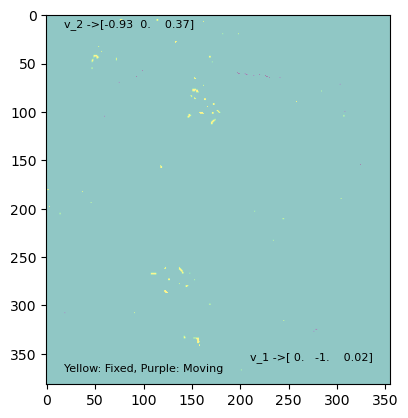

In [525]:
transform_registration= reg.register(learning_rate = 0.5, sampling_percentage = 0.3, max_iter = 100,
                                        metric_type = 'ms', optimizer_type = 'gd',
                                        smoothing = 2, shrinking = 3, thresholds=threshold,
                                        smooth_fixed = True, smooth_moving = False)
reg.resample(transform_registration)
reg.plot2d(thresholds = threshold, difference=True,moving=True)

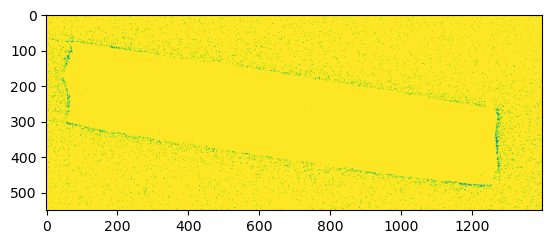

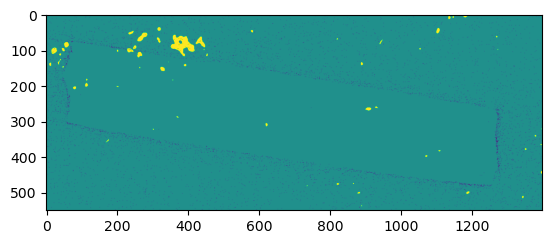

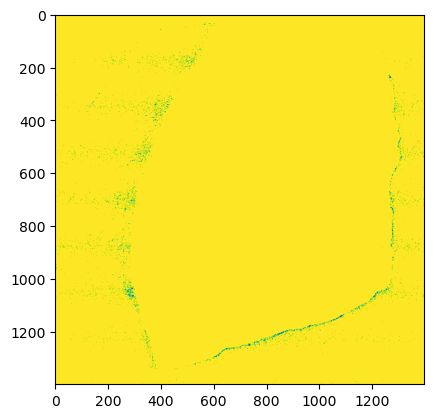

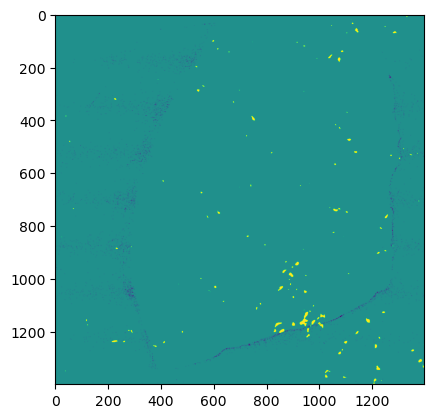

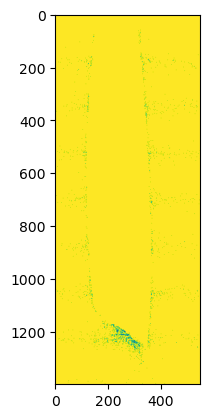

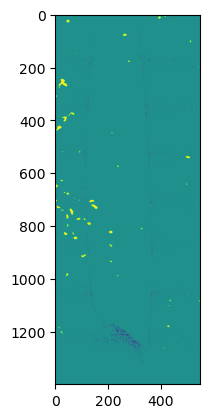

In [527]:
N_slice = 700
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[N_slice,:,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[N_slice,:,:]>threshold[1]))
plt.show()

N_slice = 350
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,N_slice,:]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,N_slice,:]>threshold[1]))
plt.show()

N_slice = 350
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1)
plt.show()
plt.figure()
plt.imshow((sitk.GetArrayFromImage(reg.fixed)[:,:,N_slice]>threshold[0])*1 - 1*(sitk.GetArrayFromImage(reg.moving)[:,:,N_slice]>threshold[1]))
plt.show()

#### Saving the (xray) data

In [ ]:
xray_data = sitk.GetArrayFromImage(reg.moving)[:,200:-200,50:-50]
n3,n2,n1 = np.shape(xray_data)
ig = ImageGeometry(voxel_num_x=n1, voxel_num_y=n2, voxel_num_z=n3)

In [ ]:
xray_data = ImageData(xray_data, geometry=ig)
writer = TIFFWriter(data=xray_data, file_name='/dtu-compute/msaca/sliceB_xray_dtu/sliceB_xray_registered/registered_to_neutron/',
counter_offset=0, compression=None)
writer.write()

Transformations returned by .transformation() and .register() have an attribute called .FLAG. It can be accessed by transform.FLAG. .resample() checks if .FLAG is True, and if that is the case, the resampling is not carried out. .register sets transform.FLAG = True of the loss function value at the end of an optimization loop is higher than at the beginning. To carry out the resampling anyway, you can simply overwrite this by setting transform.FLAG = False.

Each transformatoin also has a unique ID. Transformations with the same ID cannot be used .resample more than once. You can access the sequence of transformations used in .resample by printing reg.called_inputs

The class Registrator has an attribute/member called .callback.
reg.callback is initialized to 1, which ensures that informatio nabout the optimization is printed out. Callback can be set to zero, to disable this. But currently the .FLAG requires that callback is set to 1.